In [ ]:
pip install category_encoders


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.2 MB/s eta 0:00:00


In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00


In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

#функции для парсинга xml
def parse_xml_to_dataset(xml_content, dictitem_strategy='most_common'):
    root = ET.fromstring(xml_content)
    data = []

    for sentence_idx, sentence in enumerate(root.findall('.//sentence')):
        #собираем слова с непустым атрибутом original
        words = []

        for elem in sentence:
            if elem.tag == 'word' and 'original' in elem.attrib and elem.attrib['original'].strip():
                words.append(elem)

        #обрабатываем каждое слово
        for word_idx, word in enumerate(words):
            word_data = extract_word_features(word, word_idx, words, sentence_idx, dictitem_strategy)
            data.append(word_data)

    return pd.DataFrame(data)

def select_dictitem(dictitems, strategy):
    if not dictitems:
        return None

    if strategy == 'first':
        return dictitems[0]
    elif strategy == 'last':
        return dictitems[-1]
    elif strategy == 'most_common':
        max_weight = -1
        best_dictitem = None
        for dictitem in dictitems:
            weight = float(dictitem.attrib.get('weight', 0))
            if weight > max_weight:
                max_weight = weight
                best_dictitem = dictitem
        return best_dictitem
    else:
        return dictitems[0]

def extract_word_features(word_elem, word_index, all_words, sentence_idx, dictitem_strategy='most_common'):
    features = {}

    #базовые атрибуты слова
    features['original'] = word_elem.attrib.get('original', '')
    features['nucleus'] = int(word_elem.attrib.get('nucleus', 0)) == 2

    #признаки из dictitem
    dictitems = word_elem.findall('dictitem')
    features['total_dictitems'] = len(dictitems)

    selected_dictitem = select_dictitem(dictitems, dictitem_strategy)

    if selected_dictitem is not None:
        features['subpart_of_speech'] = selected_dictitem.attrib.get('subpart_of_speech', '0')
        features['form'] = selected_dictitem.attrib.get('form', '0')
        features['genesys'] = selected_dictitem.attrib.get('genesys', '0')
        features['semantics1'] = selected_dictitem.attrib.get('semantics1', '0')
        features['semantics2'] = selected_dictitem.attrib.get('semantics2', '0')
        features['weight'] = float(selected_dictitem.attrib.get('weight', 0))
    else:
        #значения по умолчанию
        features['subpart_of_speech'] = '0'
        features['form'] = '0'
        features['genesys'] = '0'
        features['semantics1'] = '0'
        features['semantics2'] = '0'
        features['weight'] = 0.0

    #фонетические признаки - ищем ударение в letter тегах
    has_stress = False
    stress_power = 0
    stress_type = 0

    for letter in word_elem.findall('letter'):
        if 'stress' in letter.attrib:
            has_stress = True
            stress_power = int(letter.attrib.get('stress', 0))
            break

    features['has_stress'] = has_stress
    features['stress_power'] = stress_power
    features['stress_type'] = stress_type

    #поверхностные признаки
    features['word_length'] = len(features['original'])
    features['is_capitalized'] = features['original'][0].isupper() if features['original'] else False

    #позиционные признаки
    features['word_index_in_sentence'] = word_index
    features['words_before_count'] = word_index
    features['words_after_count'] = len(all_words) - word_index - 1
    features['sentence_length'] = len(all_words)
    features['relative_position'] = word_index / max(1, len(all_words) - 1)
    features['sentence_idx'] = sentence_idx

    #контекстуальные признаки
    features['prev_word_original'] = all_words[word_index - 1].attrib.get('original', '') if word_index > 0 else ''
    features['next_word_original'] = all_words[word_index + 1].attrib.get('original', '') if word_index < len(all_words) - 1 else ''

    #признаки из соседних dictitem
    if word_index > 0:
        prev_dictitems = all_words[word_index - 1].findall('dictitem')
        prev_selected = select_dictitem(prev_dictitems, dictitem_strategy)
        features['prev_word_pos'] = prev_selected.attrib.get('subpart_of_speech', '0') if prev_selected is not None else '0'
    else:
        features['prev_word_pos'] = '0'

    if word_index < len(all_words) - 1:
        next_dictitems = all_words[word_index + 1].findall('dictitem')
        next_selected = select_dictitem(next_dictitems, dictitem_strategy)
        features['next_word_pos'] = next_selected.attrib.get('subpart_of_speech', '0') if next_selected is not None else '0'
    else:
        features['next_word_pos'] = '0'

    #признаки пунктуации
    features['has_comma_after'] = ',' in features['original']
    features['has_dash_after'] = '-' in features['original']

    return features

def preprocess_dataset(df):
    df_processed = df.copy()

    #преобразуем категориальные признаки
    categorical_columns = [
        'subpart_of_speech', 'form', 'genesys', 'semantics1', 'semantics2',
        'prev_word_pos', 'next_word_pos'
    ]

    for col in categorical_columns:
        df_processed[col] = df_processed[col].astype('category')

    #числовые признаки
    numeric_columns = [
        'weight', 'stress_power', 'stress_type', 'word_length',
        'word_index_in_sentence', 'words_before_count', 'words_after_count',
        'sentence_length', 'relative_position', 'total_dictitems'
    ]

    for col in numeric_columns:
        df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

    #бинарные признаки
    binary_columns = ['has_stress', 'is_capitalized', 'has_comma_after', 'has_dash_after', 'nucleus']
    for col in binary_columns:
        if col in df_processed.columns:
            df_processed[col] = df_processed[col].astype(bool)

    return df_processed

class FeaturePreprocessor:
    def __init__(self):
        self.onehot_columns = []
        self.target_encoding_mappings = {}
        self.scaler = StandardScaler()
        self.fitted = False

    def manual_target_encoding(self, df, column, target_column, smoothing=10):
        global_mean = df[target_column].mean()
        group_stats = df.groupby(column)[target_column].agg(['mean', 'count'])
        encoded_values = (group_stats['mean'] * group_stats['count'] + global_mean * smoothing) / (group_stats['count'] + smoothing)
        return encoded_values.to_dict(), global_mean

    def analyze_categorical_features(self, df, categorical_columns):
        onehot_candidates = []
        target_candidates = []

        for col in categorical_columns:
            if df[col].nunique() <= 15:
                onehot_candidates.append(col)
            else:
                target_candidates.append(col)

        return onehot_candidates, target_candidates

    def fit_transform(self, df, target_column='nucleus'):
        df_processed = df.copy()

        categorical_columns = df_processed.select_dtypes(include=['category', 'object']).columns.tolist()
        numerical_columns = df_processed.select_dtypes(include=[np.number]).columns.tolist()

        #удаляем целевую переменную
        if target_column in categorical_columns:
            categorical_columns.remove(target_column)
        if target_column in numerical_columns:
            numerical_columns.remove(target_column)

        self.onehot_columns, target_encoding_columns = self.analyze_categorical_features(
            df_processed, categorical_columns
        )

        #One-Hot Encoding
        if self.onehot_columns:
            df_processed = pd.get_dummies(
                df_processed,
                columns=self.onehot_columns,
                prefix=self.onehot_columns,
                drop_first=True
            )

        #Target Encoding
        if target_encoding_columns:
            for col in target_encoding_columns:
                encoding_map, global_mean = self.manual_target_encoding(
                    df_processed, col, target_column
                )

                self.target_encoding_mappings[col] = {
                    'mapping': encoding_map,
                    'global_mean': global_mean
                }

                df_processed[col + '_target_enc'] = df_processed[col].map(encoding_map)
                df_processed[col + '_target_enc'].fillna(global_mean, inplace=True)
                df_processed.drop(col, axis=1, inplace=True)

        #масштабирование числовых признаков
        if numerical_columns:
            self.numerical_columns = numerical_columns
            df_processed[numerical_columns] = self.scaler.fit_transform(df_processed[numerical_columns])

        self.fitted = True

        return df_processed

    def transform(self, df):
        if not self.fitted:
            raise ValueError("Сначала нужно вызвать fit_transform!")

        df_processed = df.copy()

        if self.onehot_columns:
            df_processed = pd.get_dummies(
                df_processed,
                columns=self.onehot_columns,
                prefix=self.onehot_columns,
                drop_first=True
            )

        for col, encoding_info in self.target_encoding_mappings.items():
            if col in df_processed.columns:
                mapping = encoding_info['mapping']
                global_mean = encoding_info['global_mean']

                df_processed[col + '_target_enc'] = df_processed[col].map(mapping)
                df_processed[col + '_target_enc'].fillna(global_mean, inplace=True)
                df_processed.drop(col, axis=1, inplace=True)

        if hasattr(self, 'numerical_columns'):
            numerical_columns_present = [col for col in self.numerical_columns if col in df_processed.columns]
            if numerical_columns_present:
                df_processed[numerical_columns_present] = self.scaler.transform(
                    df_processed[numerical_columns_present]
                )

        return df_processed

def prepare_final_features(df):
    X = df.copy()

    #извлекаем целевую переменную
    if 'nucleus' in X.columns:
        y = X.pop('nucleus')
    else:
        y = None

    #удаляем служебные колонки
    columns_to_drop = ['original', 'prev_word_original', 'next_word_original', 'sentence_idx']
    for col in columns_to_drop:
        if col in X.columns:
            X.drop(col, axis=1, inplace=True)

    return X, y

def align_columns(train_df, test_df):
    for col in train_df.columns:
        if col not in test_df.columns:
            test_df[col] = 0

    test_df = test_df[train_df.columns]
    return train_df, test_df

with open('/content/lab1_Dostoevsky_Procody.xml', 'r', encoding='utf-8') as f:
    xml_content = f.read()

df_raw = parse_xml_to_dataset(xml_content, dictitem_strategy='most_common')

print("Размер датасета:", df_raw.shape)
print("Колонки:", df_raw.columns.tolist())

if not df_raw.empty:
    print("Первые строки датасета:")
    print(df_raw.head(3))

    df_processed = preprocess_dataset(df_raw)

    print("После предобработки:", df_processed.shape)

    df_processed.to_csv('phrase_stress_dataset.csv', index=False, encoding='utf-8')
    print("Датасет сохранен")
else:
    print("Датасет пустой")

Размер датасета: (68732, 26)
Колонки: ['original', 'nucleus', 'total_dictitems', 'subpart_of_speech', 'form', 'genesys', 'semantics1', 'semantics2', 'weight', 'has_stress', 'stress_power', 'stress_type', 'word_length', 'is_capitalized', 'word_index_in_sentence', 'words_before_count', 'words_after_count', 'sentence_length', 'relative_position', 'sentence_idx', 'prev_word_original', 'next_word_original', 'prev_word_pos', 'next_word_pos', 'has_comma_after', 'has_dash_after']
Первые строки датасета:
     original  nucleus  total_dictitems subpart_of_speech form genesys  \
0       Идиот     True                1                 1    1       1   
1       Федор    False                1                 1    1       1   
2  Михайлович    False                2                 1    1       1   

  semantics1 semantics2  weight  has_stress  ...  words_after_count  \
0          0          0     0.0       False  ...                  0   
1         10          0     0.0       False  ...            

In [ ]:
#подготовка данных для обучения модели
X, y = prepare_final_features(df_processed)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


class SimpleFeaturePreprocessor:
    def __init__(self):
        self.onehot_columns = []
        self.scaler = StandardScaler()
        self.fitted = False

    def fit_transform(self, df):
        df_processed = df.copy()

        categorical_columns = df_processed.select_dtypes(include=['category', 'object']).columns.tolist()
        numerical_columns = df_processed.select_dtypes(include=[np.number]).columns.tolist()

        if categorical_columns:
            self.onehot_columns = categorical_columns
            df_processed = pd.get_dummies(
                df_processed,
                columns=self.onehot_columns,
                prefix=self.onehot_columns,
                drop_first=True
            )

        if numerical_columns:
            self.numerical_columns = numerical_columns
            df_processed[numerical_columns] = self.scaler.fit_transform(df_processed[numerical_columns])

        self.fitted = True
        return df_processed

    def transform(self, df):
        if not self.fitted:
            raise ValueError("Сначала нужно вызвать fit_transform!")

        df_processed = df.copy()

        if self.onehot_columns:
            df_processed = pd.get_dummies(
                df_processed,
                columns=self.onehot_columns,
                prefix=self.onehot_columns,
                drop_first=True
            )

        if hasattr(self, 'numerical_columns'):
            numerical_columns_present = [col for col in self.numerical_columns if col in df_processed.columns]
            if numerical_columns_present:
                df_processed[numerical_columns_present] = self.scaler.transform(
                    df_processed[numerical_columns_present]
                )

        return df_processed

preprocessor = SimpleFeaturePreprocessor()
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed, X_test_processed = align_columns(X_train_processed, X_test_processed)

print("После предобработки:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)

X_train_processed.to_csv('X_train_processed.csv', index=False)
X_test_processed.to_csv('X_test_processed.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)


#обучение catboost модели
categorical_features = []
for col in X_train_processed.columns:
    if X_train_processed[col].dtype == 'object' or (X_train_processed[col].nunique() <= 15 and X_train_processed[col].dtype == 'int64'):
        categorical_features.append(col)


model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    eval_metric='F1',
    auto_class_weights='Balanced'
)

model.fit(
    X_train_processed, y_train,
    eval_set=(X_test_processed, y_test),
    cat_features=categorical_features,
    plot=False,
    verbose=True
)




После предобработки:
X_train_processed: (54985, 130)
X_test_processed: (13747, 130)
0:	learn: 0.8908979	test: 0.8933992	best: 0.8933992 (0)	total: 64.2ms	remaining: 1m 4s
1:	learn: 0.8839079	test: 0.8890099	best: 0.8933992 (0)	total: 80.2ms	remaining: 40s
2:	learn: 0.8846439	test: 0.8898149	best: 0.8933992 (0)	total: 95.3ms	remaining: 31.7s
3:	learn: 0.8829596	test: 0.8879638	best: 0.8933992 (0)	total: 111ms	remaining: 27.6s
4:	learn: 0.8842481	test: 0.8883876	best: 0.8933992 (0)	total: 127ms	remaining: 25.3s
5:	learn: 0.8906664	test: 0.8926399	best: 0.8933992 (0)	total: 144ms	remaining: 23.8s
6:	learn: 0.8902751	test: 0.8917524	best: 0.8933992 (0)	total: 160ms	remaining: 22.7s
7:	learn: 0.8909954	test: 0.8921933	best: 0.8933992 (0)	total: 176ms	remaining: 21.9s
8:	learn: 0.8915700	test: 0.8915215	best: 0.8933992 (0)	total: 193ms	remaining: 21.2s
9:	learn: 0.8915765	test: 0.8922408	best: 0.8933992 (0)	total: 210ms	remaining: 20.7s
10:	learn: 0.8913453	test: 0.8921989	best: 0.8933992 (0

Метрики:
F1 Score: 0.8731
Precision: 0.8626
Recall: 0.8838


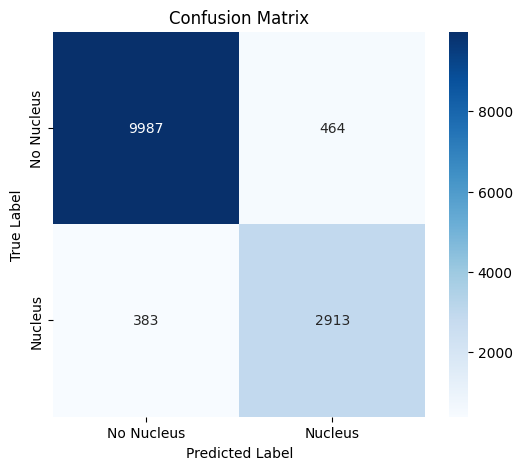

In [ ]:
#оценка модели
y_test_pred = model.predict(X_test_processed)
y_test_proba = model.predict_proba(X_test_processed)[:, 1]

test_f1 = f1_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)

print("Метрики:")
print("F1 Score:", f"{test_f1:.4f}")
print("Precision:", f"{test_precision:.4f}")
print("Recall:", f"{test_recall:.4f}")

#матрица ошибок
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Nucleus', 'Nucleus'],
            yticklabels=['No Nucleus', 'Nucleus'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()




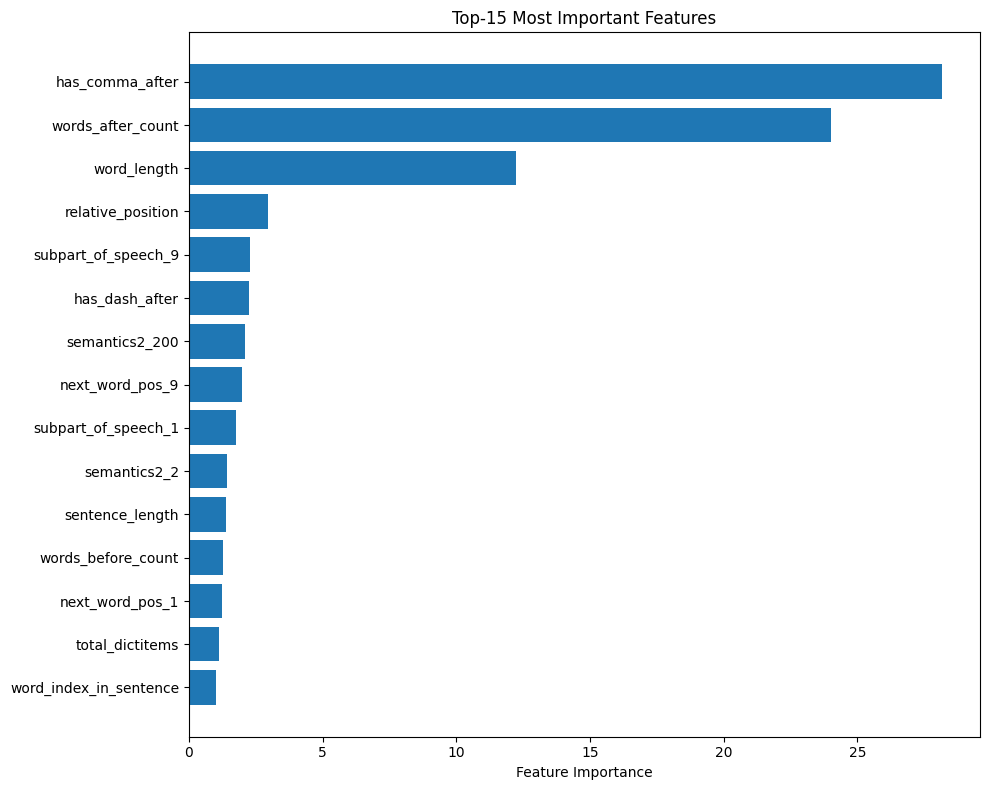

['feature_preprocessor.pkl']

In [ ]:
#важность признаков
feature_importance = model.get_feature_importance()
feature_names = X_train_processed.columns.tolist()

indices = np.argsort(feature_importance)[::-1]
top_indices = indices[:15]

plt.figure(figsize=(10, 8))
bars = plt.barh(range(len(top_indices)), feature_importance[top_indices])
plt.yticks(range(len(top_indices)), [feature_names[i] for i in top_indices])
plt.xlabel('Feature Importance')
plt.title('Top-15 Most Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

model.save_model('catboost_phrase_stress_model.cbm')
joblib.dump(preprocessor, 'feature_preprocessor.pkl')


In [ ]:
#подготавливаем датасет для предсказания пауз
def parse_xml_with_pauses(xml_content, dictitem_strategy='most_common'):
    root = ET.fromstring(xml_content)
    data = []

    for sentence_idx, sentence in enumerate(root.findall('.//sentence')):
        elements = list(sentence)

        words = [elem for elem in elements if elem.tag == 'word' and 'original' in elem.attrib and elem.attrib['original'].strip()]

        for word_idx, word in enumerate(words):
            word_data = extract_word_features_with_pause(word, words, word_idx, sentence_idx, elements, dictitem_strategy)
            if word_data:
                data.append(word_data)

    return pd.DataFrame(data)

def extract_word_features_with_pause(word_elem, all_words, word_index, sentence_idx, sentence_elements, dictitem_strategy='most_common'):
    features = {}

    features['original'] = word_elem.attrib.get('original', '')
    features['nucleus'] = int(word_elem.attrib.get('nucleus', 0)) == 2

    dictitems = word_elem.findall('dictitem')
    features['total_dictitems'] = len(dictitems)

    selected_dictitem = select_dictitem(dictitems, dictitem_strategy)

    if selected_dictitem is not None:
        features['subpart_of_speech'] = selected_dictitem.attrib.get('subpart_of_speech', '0')
        features['form'] = selected_dictitem.attrib.get('form', '0')
        features['genesys'] = selected_dictitem.attrib.get('genesys', '0')
        features['semantics1'] = selected_dictitem.attrib.get('semantics1', '0')
        features['semantics2'] = selected_dictitem.attrib.get('semantics2', '0')
        features['weight'] = float(selected_dictitem.attrib.get('weight', 0))
    else:
        features['subpart_of_speech'] = '0'
        features['form'] = '0'
        features['genesys'] = '0'
        features['semantics1'] = '0'
        features['semantics2'] = '0'
        features['weight'] = 0.0

    has_stress = False
    stress_power = 0
    for letter in word_elem.findall('letter'):
        if 'stress' in letter.attrib:
            has_stress = True
            stress_power = int(letter.attrib.get('stress', 0))
            break

    features['has_stress'] = has_stress
    features['stress_power'] = stress_power
    features['stress_type'] = 0

    features['word_length'] = len(features['original'])
    features['is_capitalized'] = features['original'][0].isupper() if features['original'] else False

    features['word_index_in_sentence'] = word_index
    features['words_before_count'] = word_index
    features['words_after_count'] = len(all_words) - word_index - 1
    features['sentence_length'] = len(all_words)
    features['relative_position'] = word_index / max(1, len(all_words) - 1)
    features['sentence_idx'] = sentence_idx

    features['prev_word_original'] = all_words[word_index - 1].attrib.get('original', '') if word_index > 0 else ''
    features['next_word_original'] = all_words[word_index + 1].attrib.get('original', '') if word_index < len(all_words) - 1 else ''

    if word_index > 0:
        prev_dictitems = all_words[word_index - 1].findall('dictitem')
        prev_selected = select_dictitem(prev_dictitems, dictitem_strategy)
        features['prev_word_pos'] = prev_selected.attrib.get('subpart_of_speech', '0') if prev_selected is not None else '0'
    else:
        features['prev_word_pos'] = '0'

    if word_index < len(all_words) - 1:
        next_dictitems = all_words[word_index + 1].findall('dictitem')
        next_selected = select_dictitem(next_dictitems, dictitem_strategy)
        features['next_word_pos'] = next_selected.attrib.get('subpart_of_speech', '0') if next_selected is not None else '0'
    else:
        features['next_word_pos'] = '0'

    features['has_comma_after'] = ',' in features['original']
    features['has_dash_after'] = '-' in features['original']
    features['has_dot_after'] = '.' in features['original']
    features['has_question_after'] = '?' in features['original']
    features['has_exclamation_after'] = '!' in features['original']

    pause_time = 0
    pause_type = 'none'

    try:
        current_idx = sentence_elements.index(word_elem)

        next_idx = current_idx + 1
        while next_idx < len(sentence_elements):
            next_elem = sentence_elements[next_idx]

            if next_elem.tag == 'pause':
                pause_time = int(next_elem.attrib.get('time', 0))
                pause_type = next_elem.attrib.get('type', 'none')
                break
            elif next_elem.tag == 'word':
                break

            next_idx += 1
    except ValueError:
        pass

    features['pause_time'] = pause_time
    features['pause_type'] = pause_type
    features['has_pause'] = pause_time > 0

    if pause_time == 0:
        return None

    return features

def preprocess_pause_dataset(df):
    df_processed = df.copy()

    categorical_columns = [
        'subpart_of_speech', 'form', 'genesys', 'semantics1', 'semantics2',
        'prev_word_pos', 'next_word_pos', 'pause_type'
    ]

    for col in categorical_columns:
        if col in df_processed.columns:
            df_processed[col] = df_processed[col].astype('category')

    numeric_columns = [
        'weight', 'stress_power', 'stress_type', 'word_length',
        'word_index_in_sentence', 'words_before_count', 'words_after_count',
        'sentence_length', 'relative_position', 'total_dictitems', 'pause_time'
    ]

    for col in numeric_columns:
        if col in df_processed.columns:
            df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')

    binary_columns = [
        'has_stress', 'is_capitalized', 'has_comma_after', 'has_dash_after',
        'has_dot_after', 'has_question_after', 'has_exclamation_after',
        'has_pause', 'nucleus'
    ]

    for col in binary_columns:
        if col in df_processed.columns:
            df_processed[col] = df_processed[col].astype(bool)

    return df_processed

class SimpleFeaturePreprocessor:
    def __init__(self):
        self.onehot_columns = []
        self.scaler = StandardScaler()
        self.fitted = False

    def fit_transform(self, df):
        df_processed = df.copy()

        categorical_columns = df_processed.select_dtypes(include=['category', 'object']).columns.tolist()
        numerical_columns = df_processed.select_dtypes(include=[np.number]).columns.tolist()

        if categorical_columns:
            self.onehot_columns = categorical_columns
            df_processed = pd.get_dummies(
                df_processed,
                columns=self.onehot_columns,
                prefix=self.onehot_columns,
                drop_first=True
            )

        if numerical_columns:
            self.numerical_columns = numerical_columns
            df_processed[numerical_columns] = self.scaler.fit_transform(df_processed[numerical_columns])

        self.fitted = True
        return df_processed

    def transform(self, df):
        if not self.fitted:
            raise ValueError("Сначала нужно вызвать fit_transform!")

        df_processed = df.copy()

        if self.onehot_columns:
            df_processed = pd.get_dummies(
                df_processed,
                columns=self.onehot_columns,
                prefix=self.onehot_columns,
                drop_first=True
            )

        if hasattr(self, 'numerical_columns'):
            numerical_columns_present = [col for col in self.numerical_columns if col in df_processed.columns]
            if numerical_columns_present:
                df_processed[numerical_columns_present] = self.scaler.transform(
                    df_processed[numerical_columns_present]
                )

        return df_processed

def prepare_pause_features(df):
    X = df.copy()

    if 'pause_time' in X.columns:
        y = X.pop('pause_time')
    else:
        y = None

    columns_to_drop = ['original', 'pause_type', 'has_pause', 'sentence_idx']
    for col in columns_to_drop:
        if col in X.columns:
            X.drop(col, axis=1, inplace=True)

    return X, y

df_pauses = parse_xml_with_pauses(xml_content, dictitem_strategy='most_common')

print("Размер датасета пауз:", df_pauses.shape)
print("Колонки:", df_pauses.columns.tolist())

if not df_pauses.empty:
    print("Всего примеров с паузами:", len(df_pauses))
    print("Средняя длина паузы:", f"{df_pauses['pause_time'].mean():.1f} мс")
    print("Минимальная пауза:", df_pauses['pause_time'].min(), "мс")
    print("Максимальная пауза:", df_pauses['pause_time'].max(), "мс")
    print("Типы пауз:", df_pauses['pause_type'].value_counts().to_dict())

    print("Первые строки:")
    print(df_pauses[['original', 'pause_time', 'pause_type', 'nucleus']].head(3))

    df_pauses_processed = preprocess_pause_dataset(df_pauses)

    print("После предобработки:", df_pauses_processed.shape)

    df_pauses_processed.to_csv('pause_prediction_dataset.csv', index=False, encoding='utf-8')

X_pause, y_pause = prepare_pause_features(df_pauses_processed)

print("Данные для регрессии:")
print("X:", X_pause.shape, "y:", y_pause.shape)
print("Средняя пауза:", f"{y_pause.mean():.1f} мс")
print("Стандартное отклонение:", f"{y_pause.std():.1f} мс")
print("Минимум:", y_pause.min(), "мс")
print("Максимум:", y_pause.max(), "мс")

X_train_pause, X_test_pause, y_train_pause, y_test_pause = train_test_split(
    X_pause, y_pause,
    test_size=0.2,
    random_state=42
)

print("Разделение данных:")
print("Train:", X_train_pause.shape)
print("Test:", X_test_pause.shape)

preprocessor_pause = SimpleFeaturePreprocessor()
X_train_pause_processed = preprocessor_pause.fit_transform(X_train_pause)
X_test_pause_processed = preprocessor_pause.transform(X_test_pause)

X_train_pause_processed, X_test_pause_processed = align_columns(X_train_pause_processed, X_test_pause_processed)

print("После предобработки:")
print("X_train_pause_processed:", X_train_pause_processed.shape)
print("X_test_pause_processed:", X_test_pause_processed.shape)

Размер датасета пауз: (16393, 32)
Колонки: ['original', 'nucleus', 'total_dictitems', 'subpart_of_speech', 'form', 'genesys', 'semantics1', 'semantics2', 'weight', 'has_stress', 'stress_power', 'stress_type', 'word_length', 'is_capitalized', 'word_index_in_sentence', 'words_before_count', 'words_after_count', 'sentence_length', 'relative_position', 'sentence_idx', 'prev_word_original', 'next_word_original', 'prev_word_pos', 'next_word_pos', 'has_comma_after', 'has_dash_after', 'has_dot_after', 'has_question_after', 'has_exclamation_after', 'pause_time', 'pause_type', 'has_pause']
Всего примеров с паузами: 16393
Средняя длина паузы: 421.1 мс
Минимальная пауза: 1 мс
Максимальная пауза: 2193 мс
Типы пауз: {'weak': 10570, 'long': 4212, 'x-long': 1579, 'spelling': 32}
Первые строки:
      original  pause_time pause_type  nucleus
0        Идиот         577       long     True
1  Достоевский        1376     x-long     True
2     "Идиот".        1020     x-long     True
После предобработки: (1

Выходные данные были обрезаны до нескольких последних строк (5000).
/tmp/ipython-input-1375982626.py:290: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[col] = 0
/tmp/ipython-input-1375982626.py:290: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df[col] = 0
/tmp/ipython-input-1375982626.py:290: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a 

После предобработки:
X_train_pause_processed: (13114, 7112)
X_test_pause_processed: (3279, 7112)


In [ ]:
# Обучение модели регрессии
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Определяем категориальные признаки
categorical_features_pause = []
for col in X_train_pause_processed.columns:
    if X_train_pause_processed[col].dtype == 'object' or (X_train_pause_processed[col].nunique() <= 15 and X_train_pause_processed[col].dtype == 'int64'):
        categorical_features_pause.append(col)


# Создаем и обучаем модель регрессии
model_pause = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50,
    eval_metric='RMSE'
)

model_pause.fit(
    X_train_pause_processed, y_train_pause,
    eval_set=(X_test_pause_processed, y_test_pause),
    cat_features=categorical_features_pause,
    plot=False,
    verbose=True
)


# Предсказания
y_test_pause_pred = model_pause.predict(X_test_pause_processed)



0:	learn: 256.3671033	test: 249.9785127	best: 249.9785127 (0)	total: 45.9ms	remaining: 45.8s
1:	learn: 240.5934805	test: 234.0560567	best: 234.0560567 (1)	total: 87.4ms	remaining: 43.6s
2:	learn: 226.9273906	test: 220.2494299	best: 220.2494299 (2)	total: 128ms	remaining: 42.5s
3:	learn: 215.2926577	test: 208.4683058	best: 208.4683058 (3)	total: 163ms	remaining: 40.6s
4:	learn: 205.3843018	test: 198.4213639	best: 198.4213639 (4)	total: 202ms	remaining: 40.2s
5:	learn: 196.9764055	test: 189.8773723	best: 189.8773723 (5)	total: 250ms	remaining: 41.4s
6:	learn: 189.8474836	test: 182.6251906	best: 182.6251906 (6)	total: 294ms	remaining: 41.7s
7:	learn: 183.9043710	test: 176.5613022	best: 176.5613022 (7)	total: 338ms	remaining: 42s
8:	learn: 178.9504026	test: 171.4939685	best: 171.4939685 (8)	total: 387ms	remaining: 42.6s
9:	learn: 174.7656772	test: 167.1878093	best: 167.1878093 (9)	total: 442ms	remaining: 43.7s
10:	learn: 171.2957872	test: 163.6135068	best: 163.6135068 (10)	total: 495ms	rem

In [ ]:
# Метрики регрессии
test_mae = mean_absolute_error(y_test_pause, y_test_pause_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_pause, y_test_pause_pred))
test_r2 = r2_score(y_test_pause, y_test_pause_pred)

print(f"📊 Результаты модели предсказания пауз:")
print(f"   - MAE: {test_mae:.1f} мс")
print(f"   - RMSE: {test_rmse:.1f} мс")
print(f"   - R²: {test_r2:.4f}")


📊 Результаты модели предсказания пауз:
   - MAE: 107.2 мс
   - RMSE: 146.4 мс
   - R²: 0.7023
